In [10]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:

df = pd.read_csv("../data/raw/train.csv")

In [4]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

<Axes: xlabel='SalePrice', ylabel='Count'>

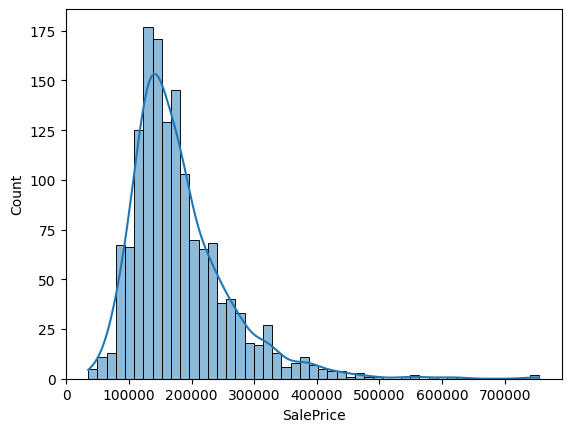

In [8]:
import seaborn as sns
sns.histplot(df["SalePrice"], kde=True)

In [11]:
df["SalePrice"] = np.log1p(df["SalePrice"])

In [13]:
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
390,391,50,RL,50.0,8405,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2008,WD,Normal,11.686887
678,679,20,RL,80.0,11844,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,New,Partial,12.827995
391,392,60,RL,71.0,12209,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,12.278398
1034,1035,30,RL,50.0,6305,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,11.693170
1197,1198,75,RM,65.0,8850,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,7,2006,ConLw,Normal,11.877576


In [15]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


In [16]:
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355879
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

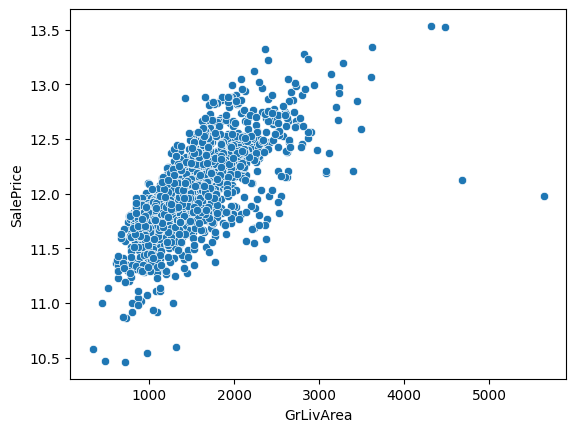

In [17]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

In [18]:
df = df[df["GrLivArea"] < 4000]

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

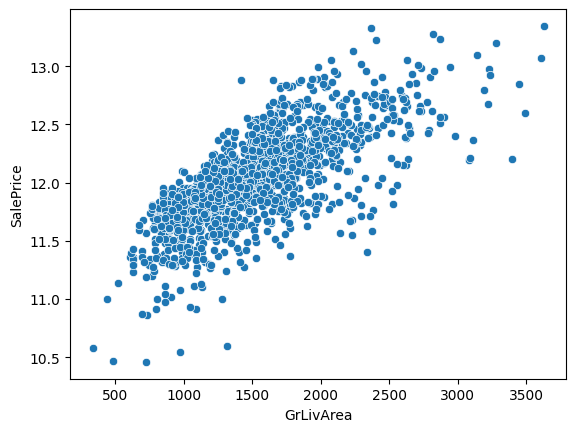

In [19]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

In [20]:
df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards     98
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     39
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [ ]:
import os
# Save processed dataset
df.to_csv("../data/processed/train.csv", index=False)

print("✅ Processed data saved to data/processed/train.csv")

✅ Processed data saved to data/processed/train.csv
